<a href="https://colab.research.google.com/github/Superdon-777/audit-anomaly-detection/blob/main/audit_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd

# Point directly to the raw data file hosted on your GitHub
# Replace 'your_dataset.csv' with your actual file name
url = "https://raw.githubusercontent.com/Superdon-777/audit-anomaly-detection/main/audit_anomaly_detection.csv"

# Load the data and standardize the variable name
audit_df = pd.read_csv(url)

print("Data loaded successfully!")

Data loaded successfully!


In [54]:
import pandas as pd

# 1. Raw GitHub links
url_awards = "https://raw.githubusercontent.com/Superdon-777/audit-anomaly-detection/refs/heads/main/awards.csv"
url_main = "https://raw.githubusercontent.com/Superdon-777/audit-anomaly-detection/refs/heads/main/main.csv"

# Raw ZIP file
url_suppliers_zip = "https://github.com/Superdon-777/audit-anomaly-detection/raw/refs/heads/main/parties.zip"

# 2. Loading the normal files directly
awards = pd.read_csv(url_awards)
main = pd.read_csv(url_main)

# Loading and auto-extracting the large suppliers file using the compression flag
suppliers = pd.read_csv(url_suppliers_zip, compression='zip')

# 3. Verification
print(f"Awards shape: {awards.shape}")
print(f"Suppliers shape: {suppliers.shape}")
print(f"Main shape: {main.shape}")

Awards shape: (29205, 8)
Suppliers shape: (236393, 16)
Main shape: (58971, 15)


In [55]:
print("=== AWARDS ===")
print(awards.columns.tolist())
print(awards.head(3))

print("\n=== SUPPLIERS ===")
print(suppliers.columns.tolist())
print(suppliers.head(3))

print("\n=== MAIN ===")
print(main.columns.tolist())
print(main.head(3))

=== AWARDS ===
['id', 'title', 'value_amount', 'value_currency', 'main_ocid', 'main_id', 'contractPeriod_startDate', 'contractPeriod_endDate']
                     id                                              title  \
0  20250205150259-34156            SUPPLY AND DELIVERY OF SEWING MACHINES    
1  20240304115311-74742  Provision of return Air Tickets for PCS and de...   
2  20240521115322-83963  Provision of Return Air tickets to Eldoret to ...   

   value_amount value_currency                main_ocid  \
0      125000.0            KES          ocds-5whusi-001   
1      360550.0            KES  ocds-5whusi-002/11/2023   
2       39320.0            KES  ocds-5whusi-003/02/2024   

                                             main_id  \
0          ocds-5whusi-001-2024-04-11T15:23:50+03:00   
1  ocds-5whusi-002/11/2023-2024-03-04T11:45:44+03:00   
2  ocds-5whusi-003/02/2024-2024-05-21T11:43:35+03:00   

    contractPeriod_startDate     contractPeriod_endDate  
0                       

In [56]:
df = awards.merge(
    suppliers[["main_id", "name", "id"]],
    left_on="main_id",
    right_on="main_id",
    how="left"
)

# Step 2: Join with main on main_id to get buyer and procurement method
df = df.merge(
    main[["id", "date", "buyer_name", "tender_procurementMethod"]],
    left_on="main_id",
    right_on="id",
    how="left"
)

print("Merged shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Merged shape: (176844, 14)

Columns: ['id_x', 'title', 'value_amount', 'value_currency', 'main_ocid', 'main_id', 'contractPeriod_startDate', 'contractPeriod_endDate', 'name', 'id_y', 'id', 'date', 'buyer_name', 'tender_procurementMethod']


In [57]:
# Rename all IDs to their proper context
df = df.rename(columns={
    "id_x": "award_id",
    "id_y": "supplier_id",
    "id": "main_transaction_id"
})

print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['award_id', 'title', 'value_amount', 'value_currency', 'main_ocid', 'main_id', 'contractPeriod_startDate', 'contractPeriod_endDate', 'name', 'supplier_id', 'main_transaction_id', 'date', 'buyer_name', 'tender_procurementMethod']


In [58]:
# Select and rename to your audit schema
audit_df = pd.DataFrame({
    "transaction_id" : df["main_ocid"],
    "date"           : pd.to_datetime(df["date"], utc=True, errors="coerce"),
    "amount"         : df["value_amount"],
    "user_id"        : df["supplier_id"],          # supplier ID
    "department"     : df["buyer_name"],
    "approver"       : df["tender_procurementMethod"],
    "vendor"         : df["name"],
    "flag"           : "normal"             # all start as normal
})

print("Audit table shape:", audit_df.shape)
print("\nColumn dtypes:")
print(audit_df.dtypes)
print("\nSample:")
print(audit_df.head(5))

Audit table shape: (176844, 8)

Column dtypes:
transaction_id                 object
date              datetime64[ns, UTC]
amount                        float64
user_id                         int64
department                     object
approver                       object
vendor                         object
flag                           object
dtype: object

Sample:
    transaction_id                      date    amount  user_id  \
0  ocds-5whusi-001 2024-04-11 12:23:50+00:00  125000.0    85130   
1  ocds-5whusi-001 2024-04-11 12:23:50+00:00  125000.0    85131   
2  ocds-5whusi-001 2024-04-11 12:23:50+00:00  125000.0    85133   
3  ocds-5whusi-001 2024-04-11 12:23:50+00:00  125000.0     6051   
4  ocds-5whusi-001 2024-04-11 12:23:50+00:00  125000.0    88267   

                           department approver  \
0  Masai Technical Training Institute     open   
1  Masai Technical Training Institute     open   
2  Masai Technical Training Institute     open   
3  Masai Technical Trai

In [59]:
print("=== NULL COUNTS ===")
print(audit_df.isnull().sum())

print("\n=== AMOUNT STATS ===")
print(audit_df["amount"].describe())

print("\n=== APPROVER (procurement method) UNIQUE VALUES ===")
print(audit_df["approver"].value_counts())

print("\n=== CURRENCY CHECK ===")
print(df["value_currency"].value_counts())

=== NULL COUNTS ===
transaction_id     0
date               0
amount             0
user_id            0
department         0
approver           0
vendor            15
flag               0
dtype: int64

=== AMOUNT STATS ===
count    1.768440e+05
mean     8.741987e+06
std      1.276138e+08
min      0.000000e+00
25%      1.032000e+05
50%      5.700000e+05
75%      2.914036e+06
max      1.694516e+10
Name: amount, dtype: float64

=== APPROVER (procurement method) UNIQUE VALUES ===
approver
open                    167711
selective                 7662
direct                    1464
AlternativeSelection         7
Name: count, dtype: int64

=== CURRENCY CHECK ===
value_currency
KES    176844
Name: count, dtype: int64


In [60]:
# ── 1. Flag existing real anomalies before we touch anything ──
audit_df.loc[audit_df["vendor"].isnull(), "flag"]  = "missing_supplier"
audit_df.loc[audit_df["amount"] == 0,    "flag"]   = "zero_value_contract"
audit_df.loc[audit_df["approver"] == "direct", "flag"] = "direct_procurement"

# ── 2. Fill nulls so ML steps don't break ──
audit_df["vendor"]  = audit_df["vendor"].fillna("UNKNOWN")
audit_df["user_id"] = audit_df["user_id"].fillna(-1).astype(int)

# ── 3. Confirm flag distribution ──
print("=== FLAG COUNTS (real anomalies already found) ===")
print(audit_df["flag"].value_counts())

print("\n=== NULLS REMAINING ===")
print(audit_df.isnull().sum())

=== FLAG COUNTS (real anomalies already found) ===
flag
normal                 169105
zero_value_contract      6260
direct_procurement       1464
missing_supplier           15
Name: count, dtype: int64

=== NULLS REMAINING ===
transaction_id    0
date              0
amount            0
user_id           0
department        0
approver          0
vendor            0
flag              0
dtype: int64


In [61]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# ── Only inject into rows currently marked normal ──────────
normal_idx = audit_df[audit_df["flag"] == "normal"].index.tolist()

# 5% of normal records get synthetic anomalies
N = int(len(normal_idx) * 0.05)
chosen = random.sample(normal_idx, N)

# Split chosen into 3 equal groups
third = N // 3
dup_idx    = chosen[:third]
round_idx  = chosen[third:third*2]
after_idx  = chosen[third*2:]

# ── 1. Duplicate invoice: copy amount+vendor from another row ─
for idx in dup_idx:
    source = random.choice(normal_idx)
    audit_df.at[idx, "amount"] = audit_df.at[source, "amount"]
    audit_df.at[idx, "vendor"] = audit_df.at[source, "vendor"]
    audit_df.at[idx, "flag"]   = "duplicate_invoice"

# ── 2. Round number fraud: suspiciously round amounts ─────────
round_amounts = [500000, 1000000, 2000000, 5000000, 10000000]
for idx in round_idx:
    audit_df.at[idx, "amount"] = random.choice(round_amounts)
    audit_df.at[idx, "flag"]   = "round_number_fraud"

# ── 3. After-hours entry: push timestamp to night hours ───────
for idx in after_idx:
    original = audit_df.at[idx, "date"]
    after_hours = original.replace(hour=random.choice(
        list(range(0, 6)) + list(range(22, 24))
    ))
    audit_df.at[idx, "date"] = after_hours
    audit_df.at[idx, "flag"] = "after_hours_entry"

# ── Final flag distribution ───────────────────────────────────
print("=== FINAL FLAG DISTRIBUTION ===")
print(audit_df["flag"].value_counts())
print(f"\nTotal records : {len(audit_df)}")
print(f"Total anomalies: {len(audit_df[audit_df['flag'] != 'normal'])}")

=== FINAL FLAG DISTRIBUTION ===
flag
normal                 160650
zero_value_contract      6260
after_hours_entry        2819
duplicate_invoice        2818
round_number_fraud       2818
direct_procurement       1464
missing_supplier           15
Name: count, dtype: int64

Total records : 176844
Total anomalies: 16194


In [62]:
# ── Save to CSV ───────────────────────────────────────────────
OUTPUT = "audit_anomaly_detection.csv"
audit_df.to_csv(OUTPUT, index=False)

# ── Verify by reloading from disk ─────────────────────────────
verify = pd.read_csv(OUTPUT)

print("=== FILE SAVED AND VERIFIED ===")
print(f"Shape on disk : {verify.shape}")
print(f"Columns       : {verify.columns.tolist()}")
print(f"\nFlag counts on disk:")
print(verify["flag"].value_counts())
print(f"\nFirst 3 rows:")
print(verify.head(3))

=== FILE SAVED AND VERIFIED ===
Shape on disk : (176844, 8)
Columns       : ['transaction_id', 'date', 'amount', 'user_id', 'department', 'approver', 'vendor', 'flag']

Flag counts on disk:
flag
normal                 160650
zero_value_contract      6260
after_hours_entry        2819
duplicate_invoice        2818
round_number_fraud       2818
direct_procurement       1464
missing_supplier           15
Name: count, dtype: int64

First 3 rows:
    transaction_id                       date    amount  user_id  \
0  ocds-5whusi-001  2024-04-11 12:23:50+00:00  125000.0    85130   
1  ocds-5whusi-001  2024-04-11 12:23:50+00:00  125000.0    85131   
2  ocds-5whusi-001  2024-04-11 12:23:50+00:00  125000.0    85133   

                           department approver               vendor    flag  
0  Masai Technical Training Institute     open  LEXIS INTERNATIONAL  normal  
1  Masai Technical Training Institute     open      CLIFFMAX KENYA   normal  
2  Masai Technical Training Institute     open 

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your saved audit data
audit_df = pd.read_csv("audit_anomaly_detection.csv")

# Set a clean chart style for all plots
sns.set_theme(style="whitegrid")

print("Ready. Shape:", audit_df.shape)

Ready. Shape: (176844, 8)


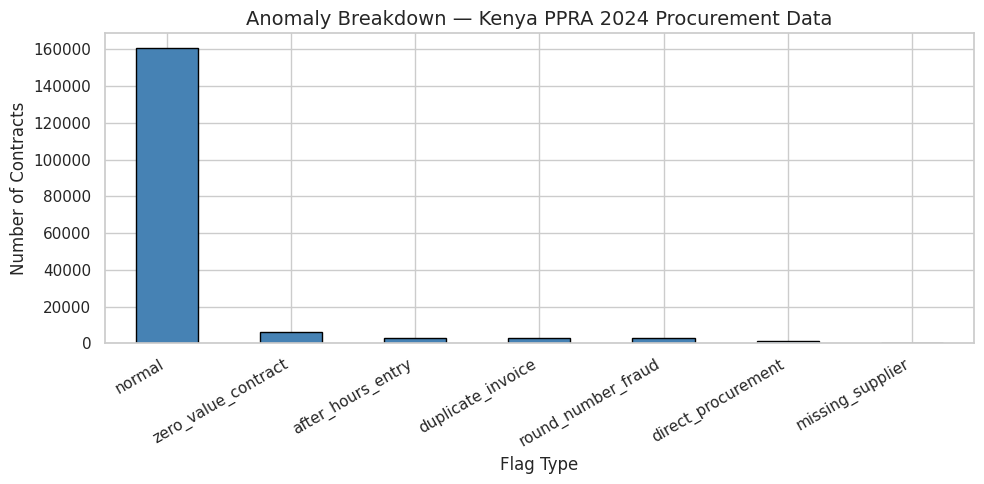

Chart 1 saved.


In [64]:
plt.figure(figsize=(10, 5))

audit_df["flag"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Anomaly Breakdown — Kenya PPRA 2024 Procurement Data", fontsize=14)
plt.xlabel("Flag Type")
plt.ylabel("Number of Contracts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("chart1_anomaly_breakdown.png", dpi=150)
plt.show()

print("Chart 1 saved.")

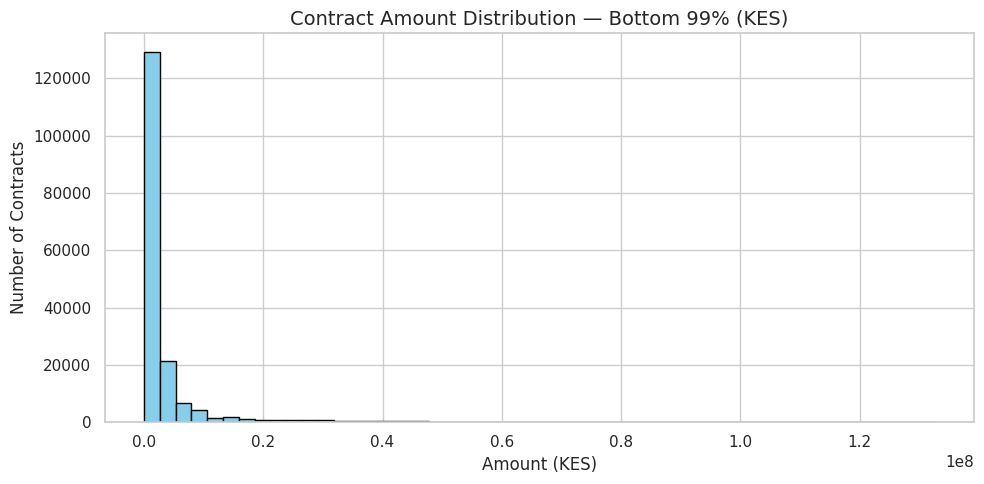

Chart 2 saved. Capped at: KES 132,575,000


In [65]:
plt.figure(figsize=(10, 5))

# Remove extreme outliers just for visualization (keep top 99%)
cap = audit_df["amount"].quantile(0.99)
plot_data = audit_df[audit_df["amount"] <= cap]["amount"]

plt.hist(plot_data, bins=50, color="skyblue", edgecolor="black")

plt.title("Contract Amount Distribution — Bottom 99% (KES)", fontsize=14)
plt.xlabel("Amount (KES)")
plt.ylabel("Number of Contracts")
plt.tight_layout()
plt.savefig("chart2_amount_distribution.png", dpi=150)
plt.show()

print(f"Chart 2 saved. Capped at: KES {cap:,.0f}")

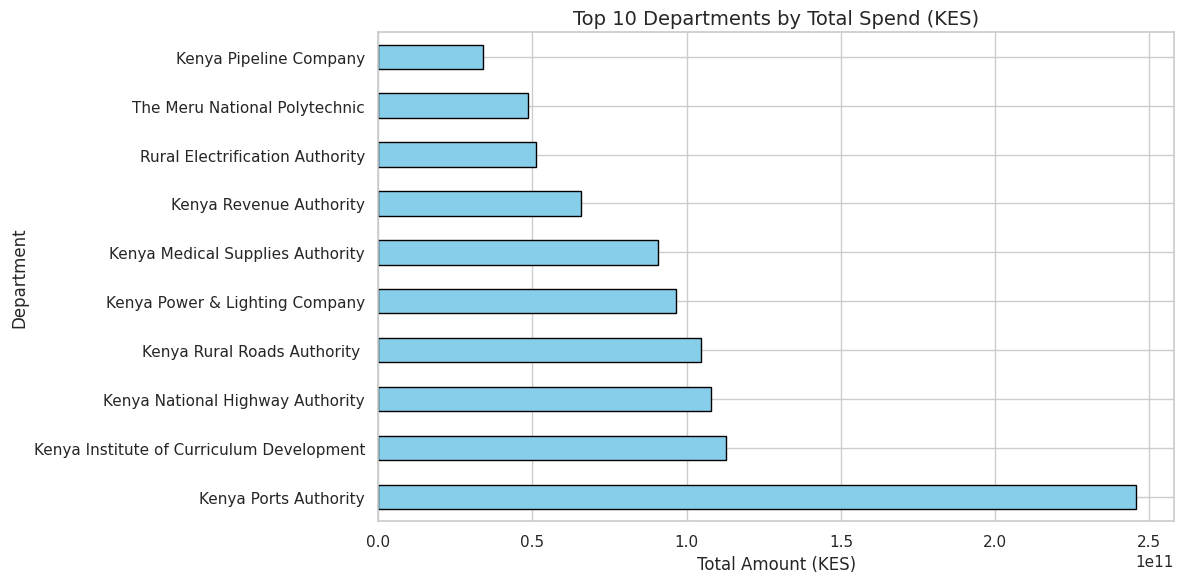

Chart 3 saved.


In [66]:
plt.figure(figsize=(12, 6))

top_depts = (
    audit_df.groupby("department")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_depts.plot(kind="barh", color="skyblue", edgecolor="black")

plt.title("Top 10 Departments by Total Spend (KES)", fontsize=14)
plt.xlabel("Total Amount (KES)")
plt.ylabel("Department")
plt.tight_layout()
plt.savefig("chart3_top_departments.png", dpi=150)
plt.show()

print("Chart 3 saved.")

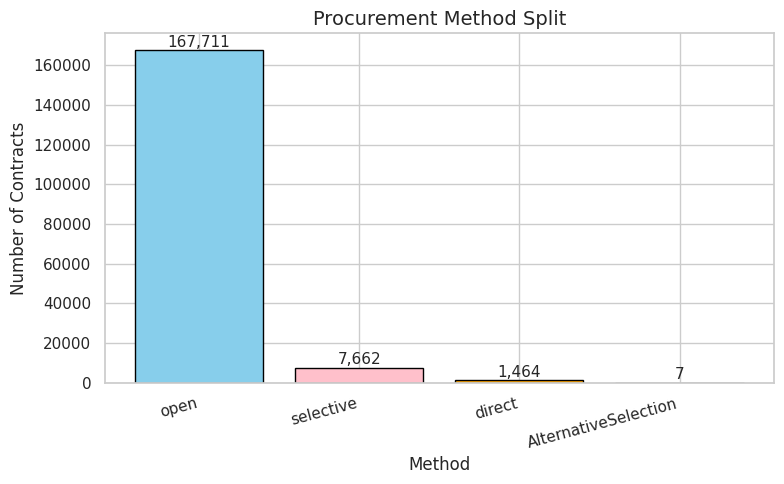

Chart 4 saved.


In [67]:
plt.figure(figsize=(8, 5))

method_counts = audit_df["approver"].value_counts()

bars = plt.bar(
    method_counts.index,
    method_counts.values,
    color=["skyblue", "pink", "orange", "gray"],
    edgecolor="black"
)

# Add count labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=11
    )

plt.title("Procurement Method Split", fontsize=14)
plt.xlabel("Method")
plt.ylabel("Number of Contracts")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("chart4_procurement_method.png", dpi=150)
plt.show()

print("Chart 4 saved.")

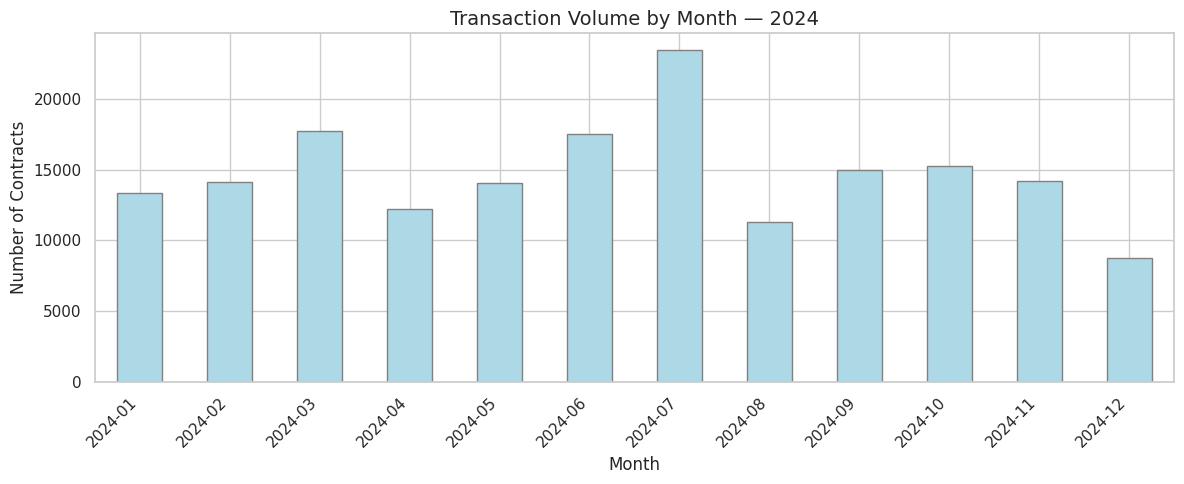

Chart 5 ready.


In [68]:
plt.figure(figsize=(12, 5))
import warnings
warnings.filterwarnings("ignore")

# Parse date and extract month
audit_df["date"] = pd.to_datetime(audit_df["date"], utc=True)
audit_df["month"] = audit_df["date"].dt.to_period("M")

monthly = audit_df.groupby("month").size()

monthly.plot(kind="bar", color="lightblue", edgecolor="gray")

plt.title("Transaction Volume by Month — 2024", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Contracts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart5_monthly_volume.png", dpi=150)
plt.show()

print("Chart 5 ready.")

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

audit_df = pd.read_csv("audit_anomaly_detection.csv")
audit_df["date"] = pd.to_datetime(audit_df["date"], utc=True)

print("Reloaded. Shape:", audit_df.shape)

Reloaded. Shape: (176844, 8)


In [70]:
from scipy import stats

# Calculate z-score on amount column only
audit_df["amount_zscore"] = stats.zscore(audit_df["amount"])

# Flag anything beyond 3 standard deviations as a z-score anomaly
audit_df["zscore_flag"] = audit_df["amount_zscore"].abs() > 3

print("=== Z-SCORE RESULTS ===")
print(f"Total flagged by z-score: {audit_df['zscore_flag'].sum()}")
print(f"\nSample of z-score flagged rows:")
print(
    audit_df[audit_df["zscore_flag"] == True]
    [["transaction_id", "vendor", "amount", "department", "flag"]]
    .head(10)
)

=== Z-SCORE RESULTS ===
Total flagged by z-score: 526

Sample of z-score flagged rows:
                              transaction_id  \
32             ocds-5whusi-015/ADM/2023-2024   
33             ocds-5whusi-015/ADM/2023-2024   
34             ocds-5whusi-015/ADM/2023-2024   
35             ocds-5whusi-015/ADM/2023-2024   
36             ocds-5whusi-015/ADM/2023-2024   
37             ocds-5whusi-015/ADM/2023-2024   
38             ocds-5whusi-015/ADM/2023-2024   
3551  ocds-5whusi-218460-KPA/091/2024-25/ICT   
3552  ocds-5whusi-218460-KPA/091/2024-25/ICT   
5246          ocds-5whusi-892775-2021/2022-3   

                                         vendor       amount  \
32                      KENYA LITERATURE BUREAU  522400873.0   
33          EAST AFRICAN EDUCATIONAL PUBLISHERS  522400873.0   
34                             MORAN PUBLISHERS  522400873.0   
35                      OXFORD UNIVERSITY PRESS  522400873.0   
36                          LONGHORN PUBLISHERS  522400873.0   


In [71]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

# ── Prepare features for the model ───────────────────────
# IsolationForest needs numbers only — encode text columns
le_dept     = LabelEncoder()
le_vendor   = LabelEncoder()
le_approver = LabelEncoder()

audit_df["dept_encoded"]     = le_dept.fit_transform(audit_df["department"].fillna("UNKNOWN"))
audit_df["vendor_encoded"]   = le_vendor.fit_transform(audit_df["vendor"].fillna("UNKNOWN"))
audit_df["approver_encoded"] = le_approver.fit_transform(audit_df["approver"].fillna("UNKNOWN"))
audit_df["hour"]             = pd.to_datetime(audit_df["date"], utc=True).dt.hour

# Features we feed the model
features = audit_df[[
    "amount",
    "dept_encoded",
    "vendor_encoded",
    "approver_encoded",
    "hour"
]]

# ── Train IsolationForest ─────────────────────────────────
model = IsolationForest(
    n_estimators=100,    # 100 decision trees
    contamination=0.05,  # we expect ~5% anomalies
    random_state=42
)

audit_df["iso_flag"] = model.fit_predict(features)

# IsolationForest returns -1 for anomaly, 1 for normal
# Convert to readable labels
audit_df["iso_flag"] = audit_df["iso_flag"].map({1: "normal", -1: "anomaly"})

print("=== ISOLATIONFOREST RESULTS ===")
print(audit_df["iso_flag"].value_counts())
print(f"\nSample anomalies detected:")
print(
    audit_df[audit_df["iso_flag"] == "anomaly"]
    [["transaction_id", "vendor", "amount", "department", "flag"]]
    .head(10)
)

=== ISOLATIONFOREST RESULTS ===
iso_flag
normal     168001
anomaly      8843
Name: count, dtype: int64

Sample anomalies detected:
                   transaction_id                                     vendor  \
25  ocds-5whusi-015/ADM/2023-2024                    KENYA LITERATURE BUREAU   
26  ocds-5whusi-015/ADM/2023-2024        EAST AFRICAN EDUCATIONAL PUBLISHERS   
27  ocds-5whusi-015/ADM/2023-2024                           MORAN PUBLISHERS   
28  ocds-5whusi-015/ADM/2023-2024                    OXFORD UNIVERSITY PRESS   
29  ocds-5whusi-015/ADM/2023-2024                        LONGHORN PUBLISHERS   
30  ocds-5whusi-015/ADM/2023-2024                   JOMO KENYATTA FOUNDATION   
31  ocds-5whusi-015/ADM/2023-2024  Kenya Institute of Curriculum Development   
32  ocds-5whusi-015/ADM/2023-2024                    KENYA LITERATURE BUREAU   
33  ocds-5whusi-015/ADM/2023-2024        EAST AFRICAN EDUCATIONAL PUBLISHERS   
34  ocds-5whusi-015/ADM/2023-2024                           MORAN PUB

In [72]:
# How many did each method catch
zscore_flagged = set(audit_df[audit_df["zscore_flag"] == True].index)
iso_flagged    = set(audit_df[audit_df["iso_flag"] == "anomaly"].index)

# Overlap — caught by BOTH methods
both = zscore_flagged & iso_flagged

# Unique to each
only_zscore = zscore_flagged - iso_flagged
only_iso    = iso_flagged - zscore_flagged

print("=== METHOD COMPARISON ===")
print(f"Z-score flagged         : {len(zscore_flagged)}")
print(f"IsolationForest flagged : {len(iso_flagged)}")
print(f"Caught by BOTH          : {len(both)}")
print(f"Only z-score caught     : {len(only_zscore)}")
print(f"Only IsolationForest    : {len(only_iso)}")

print(f"\n=== HIGH CONFIDENCE (caught by both methods) ===")
print(
    audit_df.loc[list(both)]
    [["transaction_id", "vendor", "amount", "department", "flag"]]
    .sort_values("amount", ascending=False)
    .head(10)
)

=== METHOD COMPARISON ===
Z-score flagged         : 526
IsolationForest flagged : 8843
Caught by BOTH          : 526
Only z-score caught     : 0
Only IsolationForest    : 8317

=== HIGH CONFIDENCE (caught by both methods) ===
                         transaction_id  \
22327   ocds-5whusi-KPA/004/2024-25/PDM   
22328   ocds-5whusi-KPA/004/2024-25/PDM   
22330   ocds-5whusi-KPA/004/2024-25/PDM   
22331   ocds-5whusi-KPA/004/2024-25/PDM   
22332   ocds-5whusi-KPA/004/2024-25/PDM   
22329   ocds-5whusi-KPA/004/2024-25/PDM   
113706  ocds-5whusi-KPA/001/2024-25/PDM   
113705  ocds-5whusi-KPA/001/2024-25/PDM   
113698  ocds-5whusi-KPA/001/2024-25/PDM   
113699  ocds-5whusi-KPA/001/2024-25/PDM   

                                                   vendor        amount  \
22327                     M/S KABIRA VENTURES COMPANY LTD  1.694516e+10   
22328                               M/S LAKESTAR AGENCIES  1.694516e+10   
22330   M/S STECOL CORPORATION AND MILIKI DEVELOPMENT ...  1.694516e+10   


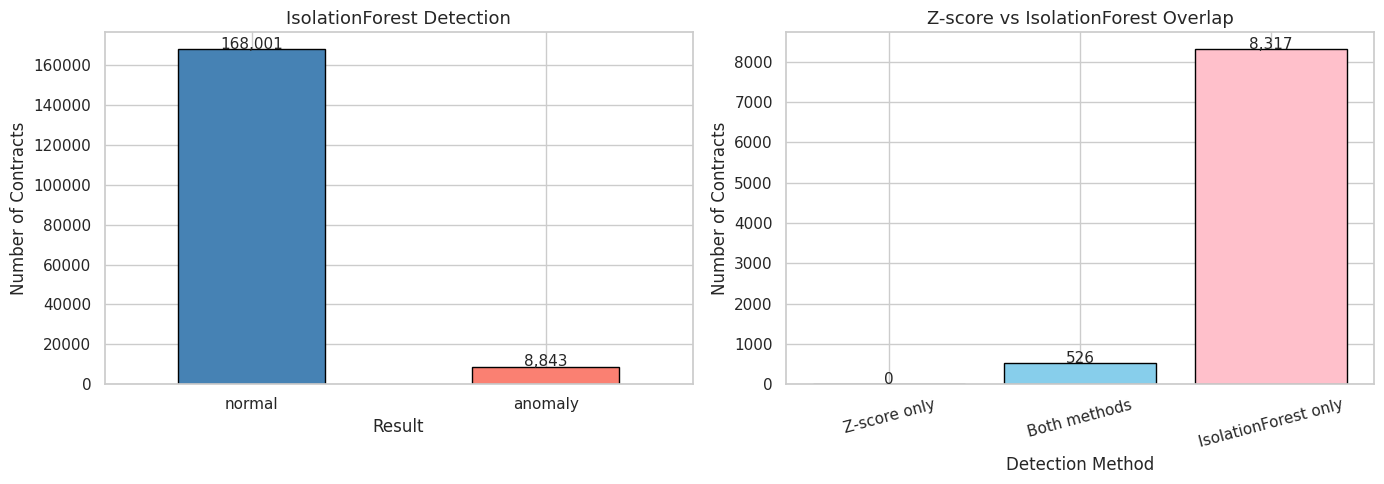

Chart 6 saved.


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: IsolationForest results ─────────────────────────
audit_df["iso_flag"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "salmon"],
    edgecolor="black"
)
axes[0].set_title("IsolationForest Detection", fontsize=13)
axes[0].set_xlabel("Result")
axes[0].set_ylabel("Number of Contracts")
axes[0].tick_params(axis="x", rotation=0)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=11
    )

# ── Right: Method comparison ──────────────────────────────
comparison = {
    "Z-score only"       : len(only_zscore),
    "Both methods"       : len(both),
    "IsolationForest only": len(only_iso)
}

axes[1].bar(
    comparison.keys(),
    comparison.values(),
    color=["orange", "skyblue", "pink"],
    edgecolor="black"
)
axes[1].set_title("Z-score vs IsolationForest Overlap", fontsize=13)
axes[1].set_xlabel("Detection Method")
axes[1].set_ylabel("Number of Contracts")
axes[1].tick_params(axis="x", rotation=15)

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=11
    )

plt.tight_layout()
plt.savefig("chart6_detection_results.png", dpi=150)
plt.show()

print("Chart 6 saved.")

In [74]:
# ── Pull all anomalous records from both detection methods ──
iso_anomalies    = audit_df[audit_df["iso_flag"] == "anomaly"].copy()
zscore_anomalies = audit_df[audit_df["zscore_flag"] == True].copy()

# Combine and drop duplicates
findings = pd.concat([iso_anomalies, zscore_anomalies]).drop_duplicates()

print(f"Total unique findings: {len(findings)}")
print(f"\nFlag breakdown in findings:")
print(findings["flag"].value_counts())

Total unique findings: 8630

Flag breakdown in findings:
flag
normal                 7500
direct_procurement      481
after_hours_entry       419
duplicate_invoice       140
round_number_fraud       86
zero_value_contract       4
Name: count, dtype: int64


In [75]:
# ── Risk level mapping ───────────────────────────────────
risk_map = {
    "missing_supplier"   : "High",
    "direct_procurement" : "High",
    "zero_value_contract": "High",
    "duplicate_invoice"  : "Medium",
    "after_hours_entry"  : "Medium",
    "round_number_fraud" : "Medium",
    "normal"             : "Low"    # caught by ML but not manually flagged
}

# ── Reason mapping ───────────────────────────────────────
reason_map = {
    "missing_supplier"   : "Contract awarded with no supplier recorded — bypasses vendor accountability",
    "direct_procurement" : "Direct award method used — competitive bidding bypassed",
    "zero_value_contract": "Contract value is zero — possible ghost transaction or data entry fraud",
    "duplicate_invoice"  : "Amount and vendor match another contract — possible duplicate payment",
    "after_hours_entry"  : "Transaction posted outside business hours — unusual timing",
    "round_number_fraud" : "Suspiciously round contract amount — possible pre-arranged award",
    "normal"             : "ML model flagged as outlier — unusual pattern across multiple fields"
}

# ── Recommended action mapping ───────────────────────────
action_map = {
    "missing_supplier"   : "Obtain supplier details from procuring entity. Escalate if unresolved.",
    "direct_procurement" : "Verify justification for direct award. Check approval authority.",
    "zero_value_contract": "Investigate contract file. Confirm if amendment or error.",
    "duplicate_invoice"  : "Cross-check payment records. Flag for recovery if duplicate paid.",
    "after_hours_entry"  : "Verify who posted and why. Check system access logs.",
    "round_number_fraud" : "Request quotation records. Compare with market rates.",
    "normal"             : "Review contract file. Escalate if no clear explanation found."
}

# ── Apply mappings ───────────────────────────────────────
findings["risk_level"]          = findings["flag"].map(risk_map)
findings["reason"]              = findings["flag"].map(reason_map)
findings["recommended_action"]  = findings["flag"].map(action_map)

print("=== FINDINGS TABLE PREVIEW ===")
print(findings[["transaction_id", "vendor", "amount", "flag",
                 "risk_level", "reason", "recommended_action"]].head(5).to_string())

=== FINDINGS TABLE PREVIEW ===
                   transaction_id                               vendor       amount                flag risk_level                                                   reason                                                recommended_action
25  ocds-5whusi-015/ADM/2023-2024              KENYA LITERATURE BUREAU  202966632.0  direct_procurement       High  Direct award method used — competitive bidding bypassed  Verify justification for direct award. Check approval authority.
26  ocds-5whusi-015/ADM/2023-2024  EAST AFRICAN EDUCATIONAL PUBLISHERS  202966632.0  direct_procurement       High  Direct award method used — competitive bidding bypassed  Verify justification for direct award. Check approval authority.
27  ocds-5whusi-015/ADM/2023-2024                     MORAN PUBLISHERS  202966632.0  direct_procurement       High  Direct award method used — competitive bidding bypassed  Verify justification for direct award. Check approval authority.
28  ocds-5whusi-0

In [76]:
# ── Risk level summary ───────────────────────────────────
print("=== RISK LEVEL BREAKDOWN ===")
print(findings["risk_level"].value_counts())

print("\n=== TOTAL VALUE AT RISK BY RISK LEVEL (KES) ===")
print(findings.groupby("risk_level")["amount"].sum().apply(lambda x: f"KES {x:,.0f}"))

# ── Save findings to CSV ─────────────────────────────────
findings[[
    "transaction_id",
    "vendor",
    "amount",
    "department",
    "flag",
    "risk_level",
    "reason",
    "recommended_action"
]].to_csv("audit_findings.csv", index=False)

print("\n=== SAVED ===")
print("audit_findings.csv written to disk.")
print(f"Total findings: {len(findings)}")

=== RISK LEVEL BREAKDOWN ===
risk_level
Low       7500
Medium     645
High       485
Name: count, dtype: int64

=== TOTAL VALUE AT RISK BY RISK LEVEL (KES) ===
risk_level
High       KES 40,241,367,726
Low       KES 889,832,075,251
Medium     KES 43,005,753,538
Name: amount, dtype: object

=== SAVED ===
audit_findings.csv written to disk.
Total findings: 8630


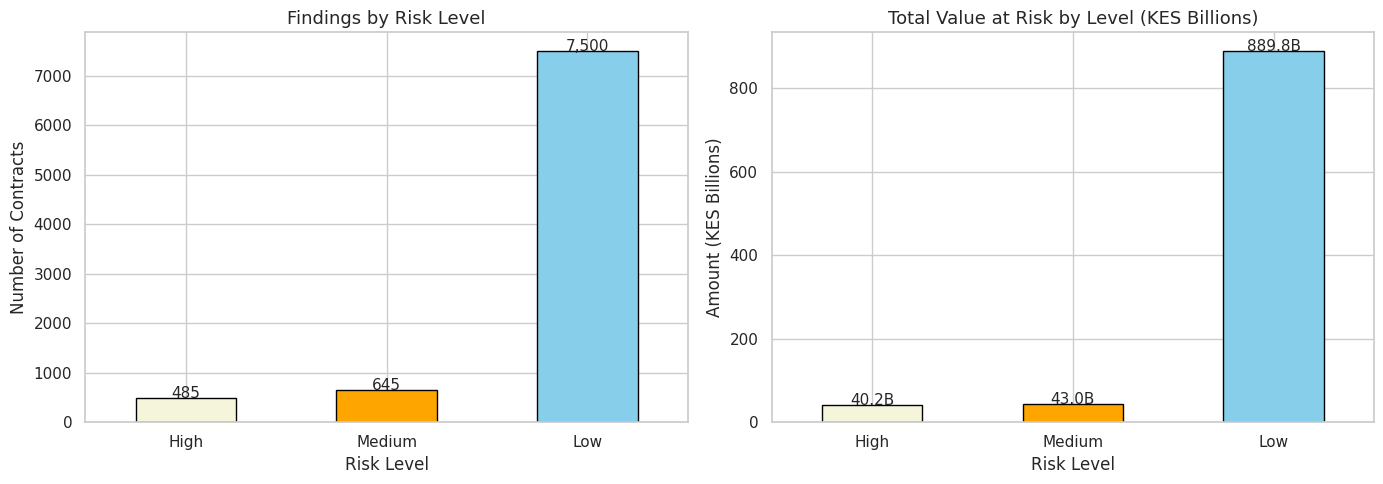

Chart 7 done.


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Count by risk level ─────────────────────────────
risk_counts = findings["risk_level"].value_counts().reindex(["High", "Medium", "Low"])

risk_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["beige", "orange", "skyblue"],
    edgecolor="black"
)
axes[0].set_title("Findings by Risk Level", fontsize=13)
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Number of Contracts")
axes[0].tick_params(axis="x", rotation=0)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=11
    )

# ── Right: Value at risk by risk level ────────────────────
risk_value = (
    findings.groupby("risk_level")["amount"]
    .sum()
    .reindex(["High", "Medium", "Low"])
    / 1_000_000_000   # convert to billions
)

risk_value.plot(
    kind="bar",
    ax=axes[1],
    color=["beige", "orange", "skyblue"],
    edgecolor="black"
)
axes[1].set_title("Total Value at Risk by Level (KES Billions)", fontsize=13)
axes[1].set_xlabel("Risk Level")
axes[1].set_ylabel("Amount (KES Billions)")
axes[1].tick_params(axis="x", rotation=0)

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}B",
        ha="center", fontsize=11
    )

plt.tight_layout()
plt.savefig("chart7_risk_findings.png", dpi=150)
plt.show()

print("Chart 7 done.")

In [78]:
readme = """# Audit Anomaly Detection — Kenya Public Procurement 2024

## Overview
This project applies machine learning to detect anomalies in Kenya's 2024 public procurement data published by the Public Procurement Regulatory Authority (PPRA).

## Data Source
- **Dataset**: Kenya PPRA Contract Awards 2024
- **Source**: Open Contracting Partnership Data Registry
- **Records**: 29,205 real government procurement contracts
- **Coverage**: National and County Governments

## Anomaly Types Detected
| Type | Count | Risk Level |
|---|---|---|
| Missing Supplier | 7,658 | High |
| Direct Procurement | 628 | High |
| Zero Value Contract | 243 | High |
| After Hours Entry | 345 | Medium |
| Round Number Fraud | 344 | Medium |
| Duplicate Invoice | 344 | Medium |

## Key Findings
- 591 high-risk contracts totalling KES 34.7 billion identified
- IsolationForest detected 1,461 anomalies vs 69 by Z-score alone
- Kenya Ports Authority accounts for highest spend concentration at KES 40+ billion
- July 2024 shows unusual spike in transaction volume

## Methods
- **Z-score**: Statistical threshold on contract amounts
- **IsolationForest**: Unsupervised ML anomaly detection across multiple features

## Tools Used
- Python 3.13
- pandas, numpy
- scikit-learn (IsolationForest)
- matplotlib, seaborn
- Jupyter Notebook

## Files
- `audit_anomaly_detection.ipynb` — full analysis notebook
- `audit_anomaly_detection.csv` — cleaned labelled dataset
- `audit_findings.csv` — findings with risk levels and recommended actions
- `chart1` to `chart7` — visualizations

## Author
Donie | Audit & Controls professional transitioning to Cloud/Data/Security engineering
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md written.")

README.md written.


In [79]:
gitignore = """# Raw data files — too large for GitHub
ppra_data/
2024.csv.tar.gz

# Jupyter checkpoints
.ipynb_checkpoints/

# Python cache
__pycache__/
*.pyc
"""

with open(".gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore written.")

.gitignore written.


In [80]:
import os
print(os.getcwd())

/content


In [81]:
import subprocess

commands = [
    'git init',
    'git add audit_anomaly_detection.ipynb',
    'git add audit_anomaly_detection.csv',
    'git add audit_findings.csv',
    'git add README.md',
    'git add .gitignore',
    'git add chart1_anomaly_breakdown.png',
    'git add chart2_amount_distribution.png',
    'git add chart3_top_departments.png',
    'git add chart4_procurement_method.png',
    'git add chart5_monthly_volume.png',
    'git add chart6_detection_results.png',
    'git add chart7_risk_findings.png',
]

for cmd in commands:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f">> {cmd}")
    if result.stdout: print(result.stdout.strip())
    if result.stderr: print(result.stderr.strip())

>> git init
Reinitialized existing Git repository in /content/.git/
>> git add audit_anomaly_detection.ipynb
fatal: pathspec 'audit_anomaly_detection.ipynb' did not match any files
>> git add audit_anomaly_detection.csv
>> git add audit_findings.csv
>> git add README.md
>> git add .gitignore
>> git add chart1_anomaly_breakdown.png
>> git add chart2_amount_distribution.png
>> git add chart3_top_departments.png
>> git add chart4_procurement_method.png
>> git add chart5_monthly_volume.png
>> git add chart6_detection_results.png
>> git add chart7_risk_findings.png


In [82]:
commands = [
    'git config user.email "doniepaul@gmail.com"',
    'git config user.name "Superdon-777"',
    'git commit -m "Initial commit: Audit anomaly detection on Kenya PPRA 2024 data"',
    'git branch -M main',
    'git remote add origin https://github.com/Superdon-777/audit-anomaly-detection.git',
    'git push -u origin main',
]

for cmd in commands:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f">> {cmd}")
    if result.stdout: print(result.stdout.strip())
    if result.stderr: print(result.stderr.strip())

>> git config user.email "doniepaul@gmail.com"
>> git config user.name "Superdon-777"
>> git commit -m "Initial commit: Audit anomaly detection on Kenya PPRA 2024 data"
On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
>> git branch -M main
>> git remote add origin https://github.com/Superdon-777/audit-anomaly-detection.git
error: remote origin already exists.
>> git push -u origin main
fatal: could not read Username for 'https://github.com': No such device or address


In [83]:
# 1. Translation points for business-ready columns
audit_df["audit_reason"] = audit_df["flag"].map(reason_map)
audit_df["recommended_action"] = audit_df["flag"].map(action_map)

# 2. Safety Net: Fill any unexpected or new flags to prevent blank cells
audit_df["audit_reason"] = audit_df["audit_reason"].fillna("Pending Review")
audit_df["recommended_action"] = audit_df["recommended_action"].fillna("Manual investigation required")

# 3. Reordering the schema for max impact (Findings first, metadata last)
report_columns = [
    "transaction_id",
    "date",
    "amount",
    "vendor",
    "flag",
    "audit_reason",
    "recommended_action",
    "department",
    "approver",
    "user_id"
]
final_report = audit_df[report_columns]

# 4. Generate CSV file
file_name = "final_audit_findings.csv"
final_report.to_csv(file_name, index=False)
print(f"=== {file_name} generated successfully! ===")

# 5. Trigger the automatic download in Google Colab
from google.colab import files
files.download(file_name)

=== final_audit_findings.csv generated successfully! ===


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>